 Đã load basket_bool thành công!
Kích thước dữ liệu: (18021, 4007)
Đang tìm tập phổ biến với FP-Growth...
 Tìm thấy 400 tập phổ biến.


,support,itemsets
0,0.119971,(WHITE HANGING HEART T-LIGHT HOLDER)
58,0.107375,(JUMBO BAG RED RETROSPOT)
159,0.093502,(REGENCY CAKESTAND 3 TIER)
238,0.088397,(PARTY BUNTING)
19,0.077243,(LUNCH BAG RED RETROSPOT)
4,0.076078,(ASSORTED COLOUR BIRD ORNAMENT)
249,0.068864,(SET OF 3 CAKE TINS PANTRY DESIGN )
48,0.067643,(NATURAL SLATE HEART CHALKBOARD )
98,0.067477,(LUNCH BAG BLACK SKULL.)
49,0.064591,(HEART OF WICKER SMALL)


Đang sinh luật kết hợp...
 Sinh ra 218 luật.


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedents_str,consequents_str,rule_str
188,(WOODEN HEART CHRISTMAS SCANDINAVIAN),(WOODEN STAR CHRISTMAS SCANDINAVIAN),0.028245,0.026580,0.020421,0.722986,27.200282,1.0,0.019670,3.513977,0.991233,0.593548,0.715422,0.745627,WOODEN HEART CHRISTMAS SCANDINAVIAN,WOODEN STAR CHRISTMAS SCANDINAVIAN,WOODEN HEART CHRISTMAS SCANDINAVIAN → WOODEN S...
189,(WOODEN STAR CHRISTMAS SCANDINAVIAN),(WOODEN HEART CHRISTMAS SCANDINAVIAN),0.026580,0.028245,0.020421,0.768267,27.200282,1.0,0.019670,4.193430,0.989538,0.593548,0.761532,0.745627,WOODEN STAR CHRISTMAS SCANDINAVIAN,WOODEN HEART CHRISTMAS SCANDINAVIAN,WOODEN STAR CHRISTMAS SCANDINAVIAN → WOODEN HE...
49,"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",(PINK REGENCY TEACUP AND SAUCER),0.038844,0.038955,0.027301,0.702857,18.043004,1.0,0.025788,3.234288,0.982750,0.540659,0.690813,0.701856,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY..."
52,(PINK REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...",0.038955,0.038844,0.027301,0.700855,18.043004,1.0,0.025788,3.213009,0.982864,0.540659,0.688765,0.701856,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER → GREEN REGENCY...
48,"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",(GREEN REGENCY TEACUP AND SAUCER),0.030242,0.051717,0.027301,0.902752,17.455471,1.0,0.025737,9.751207,0.972110,0.499492,0.897449,0.715325,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ..."


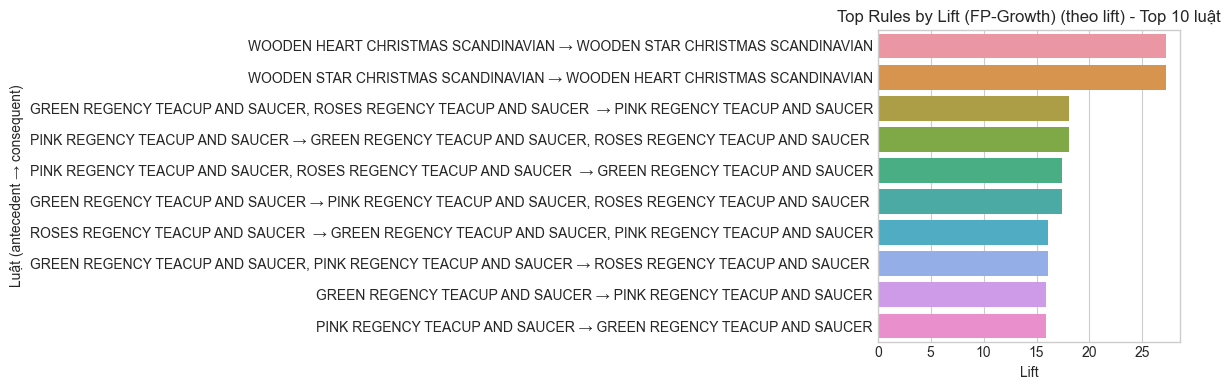

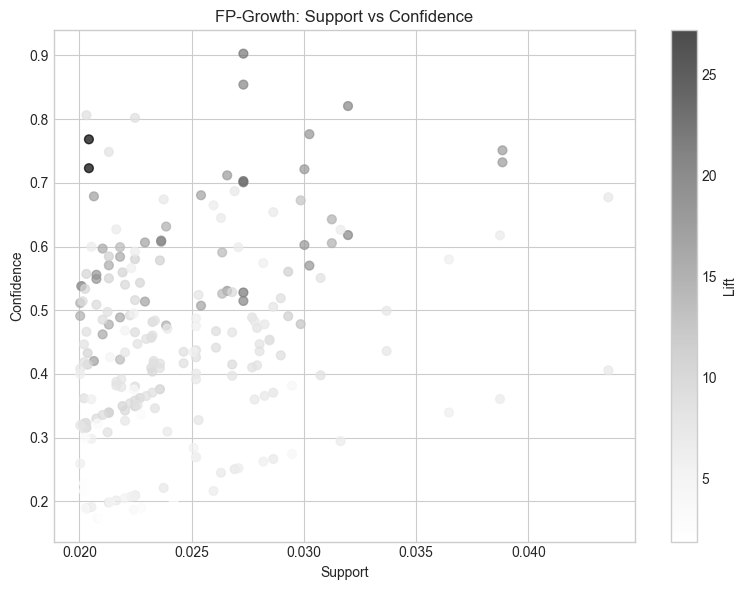

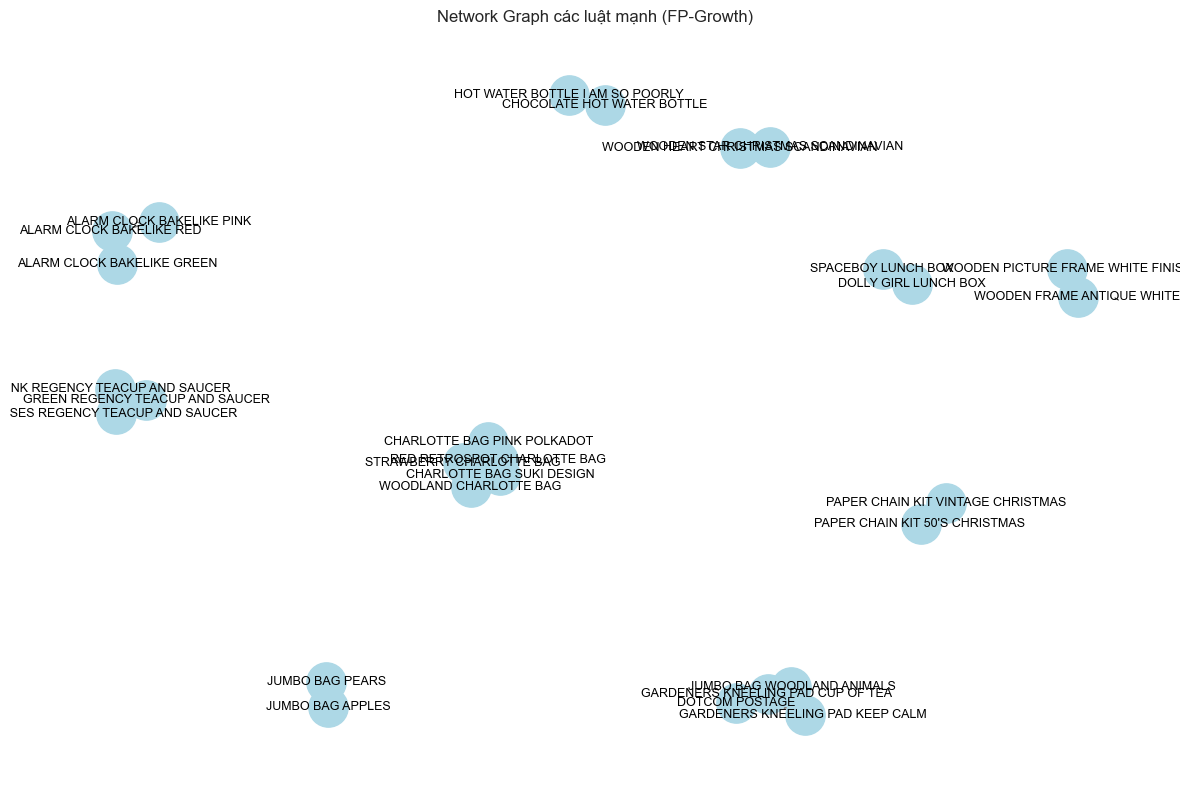

In [2]:
import warnings
# Tắt cảnh báo DeprecationWarning
warnings.filterwarnings("ignore", category=DeprecationWarning) 

import sys
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from apriori_library import AssociationRulesMiner, FPGrowthMiner

# Đọc file basket_bool.parquet đã được tạo ra từ bước basket_preparation (Lab 1)
try:
    basket_bool = pd.read_parquet('../data/processed/basket_bool.parquet')
    print(" Đã load basket_bool thành công!")
    print(f"Kích thước dữ liệu: {basket_bool.shape}")
except FileNotFoundError:
    print(" Không tìm thấy file. Hãy chạy basket_preparation.ipynb trước để tạo dữ liệu!")

# Khởi tạo miner
fp_miner = FPGrowthMiner(basket_bool)

# 1. Tìm tập phổ biến (Frequent Itemsets)
# min_support = 0.02 nghĩa là sản phẩm phải xuất hiện trong ít nhất 2% đơn hàng
print("Đang tìm tập phổ biến với FP-Growth...")
frequent_itemsets = fp_miner.mine_frequent_itemsets(min_support=0.02)

print(f" Tìm thấy {len(frequent_itemsets)} tập phổ biến.")
display(frequent_itemsets.head(10))

# 2. Sinh luật (Association Rules)
# metric="lift", min_threshold=1.0: Chỉ lấy các luật có Lift >= 1 (có ý nghĩa tích cực)
print("Đang sinh luật kết hợp...")
rules = fp_miner.generate_rules(metric="lift", min_threshold=1.0)

# Thêm cột chuỗi dễ đọc (ví dụ: "A, B -> C")
rules = fp_miner.add_readable_rule_str()

print(f" Sinh ra {len(rules)} luật.")
display(rules.head())

# Khởi tạo Visualizer
viz = DataVisualizer()

# Vẽ top 10 luật có Lift cao nhất
viz.plot_top_rules_lift(rules, top_n=10, title_prefix="Top Rules by Lift (FP-Growth)")

# Vẽ biểu đồ phân tán Support vs Confidence
viz.plot_rules_support_confidence_scatter(rules, title="FP-Growth: Support vs Confidence")

# Vẽ biểu đồ mạng lưới (Network Graph) cho 50 luật mạnh nhất
viz.plot_rules_network(rules, max_rules=50, min_lift=1.5, title="Network Graph các luật mạnh (FP-Growth)")